# CARE training notebook

This notebook trains a CARE model from a saved patch `.npz` file.

Workflow:
1. import training helpers from the Python module
2. define user settings
3. resolve the patch file and patch metadata
4. load training / validation data
5. optionally normalize patches
6. build config
7. create model
8. train
9. save history + metadata
10. inspect validation predictions

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from ISS_CARE.ISS_CARE_training import (
    resolve_patch_file,
    resolve_patch_metadata_file,
    load_json_file,
    build_model_run_name,
    load_care_training_data,
    normalize_patch_dataset,
    plot_patch_examples,
    build_care_config,
    create_care_model,
    print_model_save_info,
    train_care_model,
    save_training_history,
    plot_training_curves,
    predict_on_validation_examples,
    build_training_metadata,
    save_training_metadata,
)

## User settings

Set the patch file, training hyperparameters, and normalization behavior here.

Notes:
- `MODEL_NAME` is auto-generated later from the patch file name + timestamp.
- `TRAIN_LOSS="mae"` is recommended for your Leica 40x denoising setup.
- `UNET_N_DEPTH=2` is a good fit for your current patch dataset size.

In [18]:
# ----------------------------
# User settings
# ----------------------------

HOME = Path.home()
CARE_ROOT = HOME / "moldia-archive" / "CARE_training"
CARE_ROOT = CARE_ROOT.expanduser().resolve()

# Patch file to train on
PATCH_FILE_NAME = "DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47.npz"
# PATCH_FILE_NAME = "DAPI_ONLY_train_patches_Leica40X_final.npz"

# Model output
MODEL_DIRNAME = "care_models"
MODEL_DIR = CARE_ROOT / MODEL_DIRNAME

# MODEL_NAME is built automatically later from patch file + timestamp
MODEL_NAME = None

# Validation split
VALIDATION_SPLIT = 0.1

# Training parameters
TRAIN_BATCH_SIZE = 8
TRAIN_STEPS_PER_EPOCH = 30
TRAIN_EPOCHS = 100

# Model parameters
UNET_KERN_SIZE = 3
UNET_N_DEPTH = 2
TRAIN_LEARNING_RATE = 2e-4
TRAIN_LOSS = "mae"
PROBABILISTIC = False

# Optional normalization
# Recommended: True for your mixed Leica 40x training patches
NORMALIZE_PATCHES = False
NORMALIZATION_PMIN = 1.0
NORMALIZATION_PMAX = 99.8
NORMALIZATION_EPS = 1e-8

print("CARE_ROOT:", CARE_ROOT)
print("PATCH_FILE_NAME:", PATCH_FILE_NAME)
print("MODEL_DIR:", MODEL_DIR)
print("MODEL_NAME:", MODEL_NAME, "(auto-generated later)")
print("VALIDATION_SPLIT:", VALIDATION_SPLIT)

print("\nTraining parameters:")
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("TRAIN_STEPS_PER_EPOCH:", TRAIN_STEPS_PER_EPOCH)
print("TRAIN_EPOCHS:", TRAIN_EPOCHS)

print("\nModel parameters:")
print("UNET_KERN_SIZE:", UNET_KERN_SIZE)
print("UNET_N_DEPTH:", UNET_N_DEPTH)
print("TRAIN_LEARNING_RATE:", TRAIN_LEARNING_RATE)
print("TRAIN_LOSS:", TRAIN_LOSS)
print("PROBABILISTIC:", PROBABILISTIC)

print("\nNormalization settings:")
print("NORMALIZE_PATCHES:", NORMALIZE_PATCHES)
print("NORMALIZATION_PMIN:", NORMALIZATION_PMIN)
print("NORMALIZATION_PMAX:", NORMALIZATION_PMAX)
print("NORMALIZATION_EPS:", NORMALIZATION_EPS)

CARE_ROOT: /home/sagah/moldia-archive/CARE_training
PATCH_FILE_NAME: DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47.npz
MODEL_DIR: /home/sagah/moldia-archive/CARE_training/care_models
MODEL_NAME: None (auto-generated later)
VALIDATION_SPLIT: 0.1

Training parameters:
TRAIN_BATCH_SIZE: 8
TRAIN_STEPS_PER_EPOCH: 30
TRAIN_EPOCHS: 100

Model parameters:
UNET_KERN_SIZE: 3
UNET_N_DEPTH: 2
TRAIN_LEARNING_RATE: 0.0002
TRAIN_LOSS: mae
PROBABILISTIC: False

Normalization settings:
NORMALIZE_PATCHES: False
NORMALIZATION_PMIN: 1.0
NORMALIZATION_PMAX: 99.8
NORMALIZATION_EPS: 1e-08


## Resolve patch file and patch metadata

This:
- finds the patch `.npz` file
- looks for its sidecar metadata JSON
- auto-builds a unique model run name

In [19]:
patch_dir, patch_file = resolve_patch_file(
    care_root=CARE_ROOT,
    patch_file_name=PATCH_FILE_NAME,
)

MODEL_NAME = build_model_run_name(
    patch_file=patch_file,
    prefix="CARE",
)

patch_metadata_file = resolve_patch_metadata_file(patch_file)
patch_metadata = load_json_file(patch_metadata_file) if patch_metadata_file else None

print("Resolved patch dir:", patch_dir)
print("Resolved patch file:", patch_file)
print("Patch metadata file:", patch_metadata_file)
print("Auto-generated MODEL_NAME:", MODEL_NAME)

if patch_metadata is not None:
    print("\nPatch metadata keys:", sorted(patch_metadata.keys()))
    if "sample_summary" in patch_metadata and isinstance(patch_metadata["sample_summary"], dict):
        sample_summary = patch_metadata["sample_summary"]
        if "patches_per_sample" in sample_summary:
            print("\nPatches per sample:")
            for k, v in sample_summary["patches_per_sample"].items():
                print(f"  {k}: {v}")

Resolved patch dir: /home/sagah/moldia-archive/CARE_training/train_patches
Resolved patch file: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47.npz
Patch metadata file: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__metadata.json
Auto-generated MODEL_NAME: CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39

Patch metadata keys: ['X_shape', 'Y_shape', 'axes', 'global_parameters', 'hostname', 'n_pairs_used', 'n_patches_total', 'patch_file', 'patch_parameters', 'sample_summary', 'timestamp', 'user', 'variant_name']

Patches per sample:
  20250116_tonsil_S14_VDJ_new: 212
  CHK_pool1-2_SplintR_B2DO27_40X_Slide4: 77
  Chicken_3rdTrial_A2.1_E3_40X: 87
  Chicken_3rdTrial_A5.1_E5_40X: 136


## Load CARE training data

This loads:
- training input patches `X`
- training target patches `Y`
- validation input patches `X_val`
- validation target patches `Y_val`

It also prints sanity checks.

In [20]:
X, Y, X_val, Y_val, axes, n_channel_in, n_channel_out = load_care_training_data(
    patch_file=patch_file,
    validation_split=VALIDATION_SPLIT,
)

PATCH_FILE: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47.npz
Axes: SYXC
Training X: (461, 128, 128, 1)
Training Y: (461, 128, 128, 1)
Validation X: (51, 128, 128, 1)
Validation Y: (51, 128, 128, 1)
Input channels: 1
Output channels: 1
Validation split: 0.1
Patch metadata file: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__metadata.json
Patch counts per sample:
  20250116_tonsil_S14_VDJ_new: 212
  CHK_pool1-2_SplintR_B2DO27_40X_Slide4: 77
  Chicken_3rdTrial_A2.1_E3_40X: 87
  Chicken_3rdTrial_A5.1_E5_40X: 136

Patch summary (training):
  X shape: (461, 128, 128, 1)
  Y shape: (461, 128, 128, 1)
  X has NaN: False
  Y has NaN: False
  X has inf: False
  Y has inf: False
  X min/max: -0.1397121101617813 1.421499252319336
  Y min/max: -0.13556337356567383 2.874340772628784
  constant/near-constant X patches: 3
  constant/near-constant Y patche

## Optional patch preview before normalization

This is just to visually inspect a few training pairs as loaded from disk.

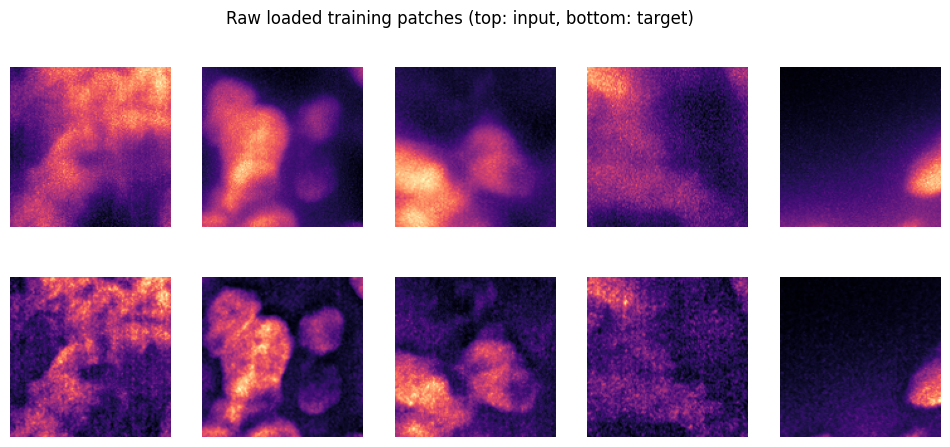

In [21]:
plot_patch_examples(
    X,
    Y,
    n_show=5,
    title="Raw loaded training patches (top: input, bottom: target)",
)

## Normalize training and validation patches

Recommended for your Leica 40x setup, especially when training across multiple biological samples.

Important:
- if you train with normalization enabled,
- you should normalize inference inputs the same way before prediction.

In [22]:
X, Y, X_val, Y_val = normalize_patch_dataset(
    X,
    Y,
    X_val,
    Y_val,
    enabled=NORMALIZE_PATCHES,
    pmin=NORMALIZATION_PMIN,
    pmax=NORMALIZATION_PMAX,
    eps=NORMALIZATION_EPS,
)


Normalization settings
Enabled: False
Percentile normalization is OFF. Raw loaded patch values will be used.



## Patch preview after normalization

This helps verify that normalization did not break the data.

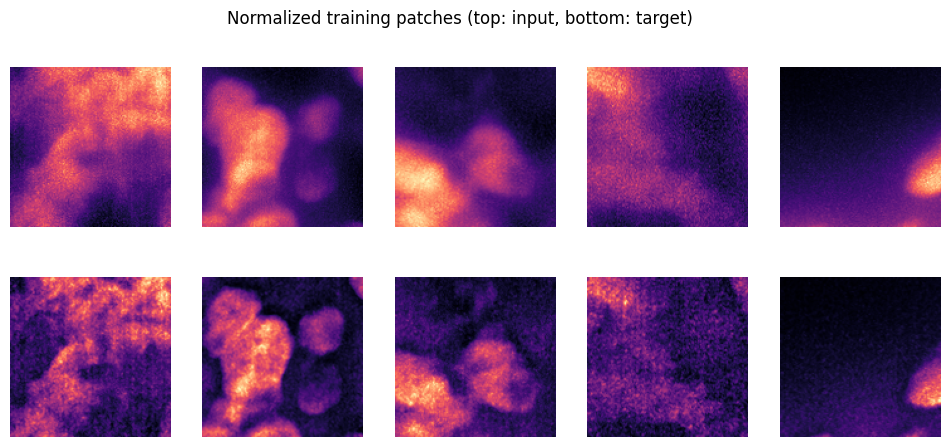

In [23]:
plot_patch_examples(
    X,
    Y,
    n_show=5,
    title="Normalized training patches (top: input, bottom: target)",
)

## Build CARE configuration

This creates the CARE training configuration from:
- patch axes
- input channels
- output channels
- training hyperparameters


In [24]:
config = build_care_config(
    axes=axes,
    n_channel_in=n_channel_in,
    n_channel_out=n_channel_out,
    train_batch_size=TRAIN_BATCH_SIZE,
    train_steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    train_epochs=TRAIN_EPOCHS,
    unet_kern_size=UNET_KERN_SIZE,
    unet_n_depth=UNET_N_DEPTH,
    train_learning_rate=TRAIN_LEARNING_RATE,
    probabilistic=PROBABILISTIC,
    train_loss=TRAIN_LOSS,
)

Using training loss: mae

Config summary:
  axes: YXC
  n_channel_in: 1
  n_channel_out: 1
  probabilistic: False
  unet_kern_size: 3
  unet_n_depth: 2
  train_batch_size: 8
  train_steps_per_epoch: 30
  train_epochs: 100
  train_learning_rate: 0.0002
  train_reduce_lr: {'factor': 0.5, 'patience': 10}
  train_loss: mae


## Create model

The model output folder is auto-named from:
- patch file stem
- timestamp

In [25]:
model = create_care_model(
    config=config,
    model_name=MODEL_NAME,
    model_dir=MODEL_DIR,
)

print_model_save_info(
    model_dir=MODEL_DIR,
    model_name=MODEL_NAME,
)

model_path = (MODEL_DIR / MODEL_NAME).resolve()
print("Model output directory:", model_path)

print("\nModel config summary:")
print("  axes:", config.axes)
print("  n_channel_in:", config.n_channel_in)
print("  n_channel_out:", config.n_channel_out)
print("  probabilistic:", config.probabilistic)
print("  kernel_size:", config.unet_kern_size)
print("  depth:", config.unet_n_depth)
print("  batch_size:", config.train_batch_size)
print("  steps_per_epoch:", config.train_steps_per_epoch)
print("  epochs:", config.train_epochs)
print("  learning_rate:", config.train_learning_rate)
print("  reduce_lr:", config.train_reduce_lr)

if hasattr(config, "train_loss"):
    print("  train_loss:", config.train_loss)


Model output locations
Model output directory: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39
CARE saves training artifacts in this directory.
Common files include:
  - weights_best.h5        (best validation checkpoint)
  - weights_last.h5        (last epoch checkpoint, depending on version/setup)
  - config.json            (model/config description)
  - training_metadata.json (run metadata from this script)
  - training_history.json  (saved training curves/metrics)

At the end of training, CARE usually restores the best checkpoint
when it prints: Loading network weights from 'weights_best.h5'.

Model output directory: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39

Model config summary:
  axes: YXC
  n_channel_in: 1
  n_channel_out: 1
  probabilistic: False
  kernel_size: 3
  depth: 2
  batch_siz

## Inspect the model architecture

In [26]:
model.keras_model._name = MODEL_NAME
model.keras_model.summary()

Model: "CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, None, None, 1)]      0         []                            
                                                                                                  
 down_level_0_no_0 (Conv2D)  (None, None, None, 32)       320       ['input[0][0]']               
                                                                                                  
 down_level_0_no_1 (Conv2D)  (None, None, None, 32)       9248      ['down_level_0_no_0[0][0]']   
                                                                                                  
 max_0 (MaxPooling2D)        (None, None, None, 32)       0         ['down_level_0_no_1[0][0]']   
           

## Train the model

This can take from minutes to hours depending on:
- dataset size
- patch size
- GPU availability
- training settings

In [27]:
history = train_care_model(
    model=model,
    X=X,
    Y=Y,
    X_val=X_val,
    Y_val=Y_val,
)

Epoch 1/100
Cause: could not parse the source code of <function _mean_or_not.<locals>.<lambda> at 0x7f9fec1423b0>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x: K.mean(x, axis=-1)

Match 1:
lambda x: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function _mean_or_not.<locals>.<lambda> at 0x7f9fec1423b0>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x: K.mean(x, axis=-1)

Match 1:
lambda x: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function _mean_or_not.<locals

## Save training history

This saves the training curves/metrics as JSON next to the model.

In [28]:
history_file = save_training_history(
    history,
    model_dir=MODEL_DIR,
    model_name=MODEL_NAME,
)

print("History file:", history_file)

Saved training history: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_history.json
History file: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_history.json


## Plot training curves

Available metrics: ['loss', 'lr', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


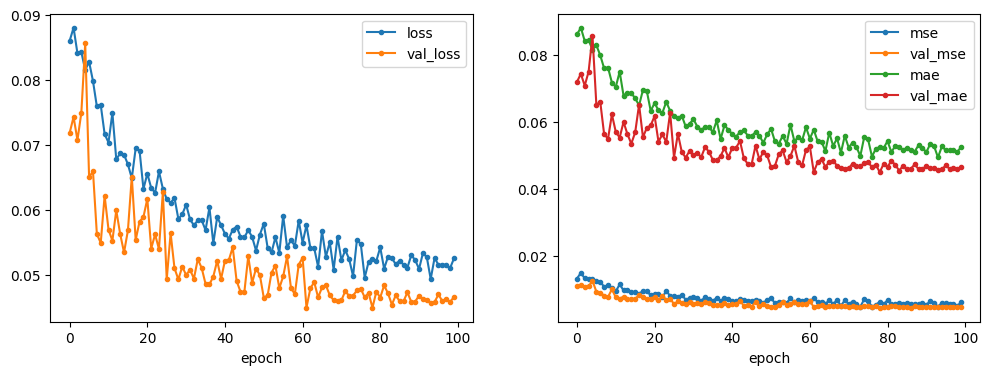

<Figure size 640x480 with 0 Axes>

In [29]:
plot_training_curves(history)

## Quick validation prediction check

This shows:
- top: input
- middle: target
- bottom: prediction

It also prints simple MAE / MSE summary values.

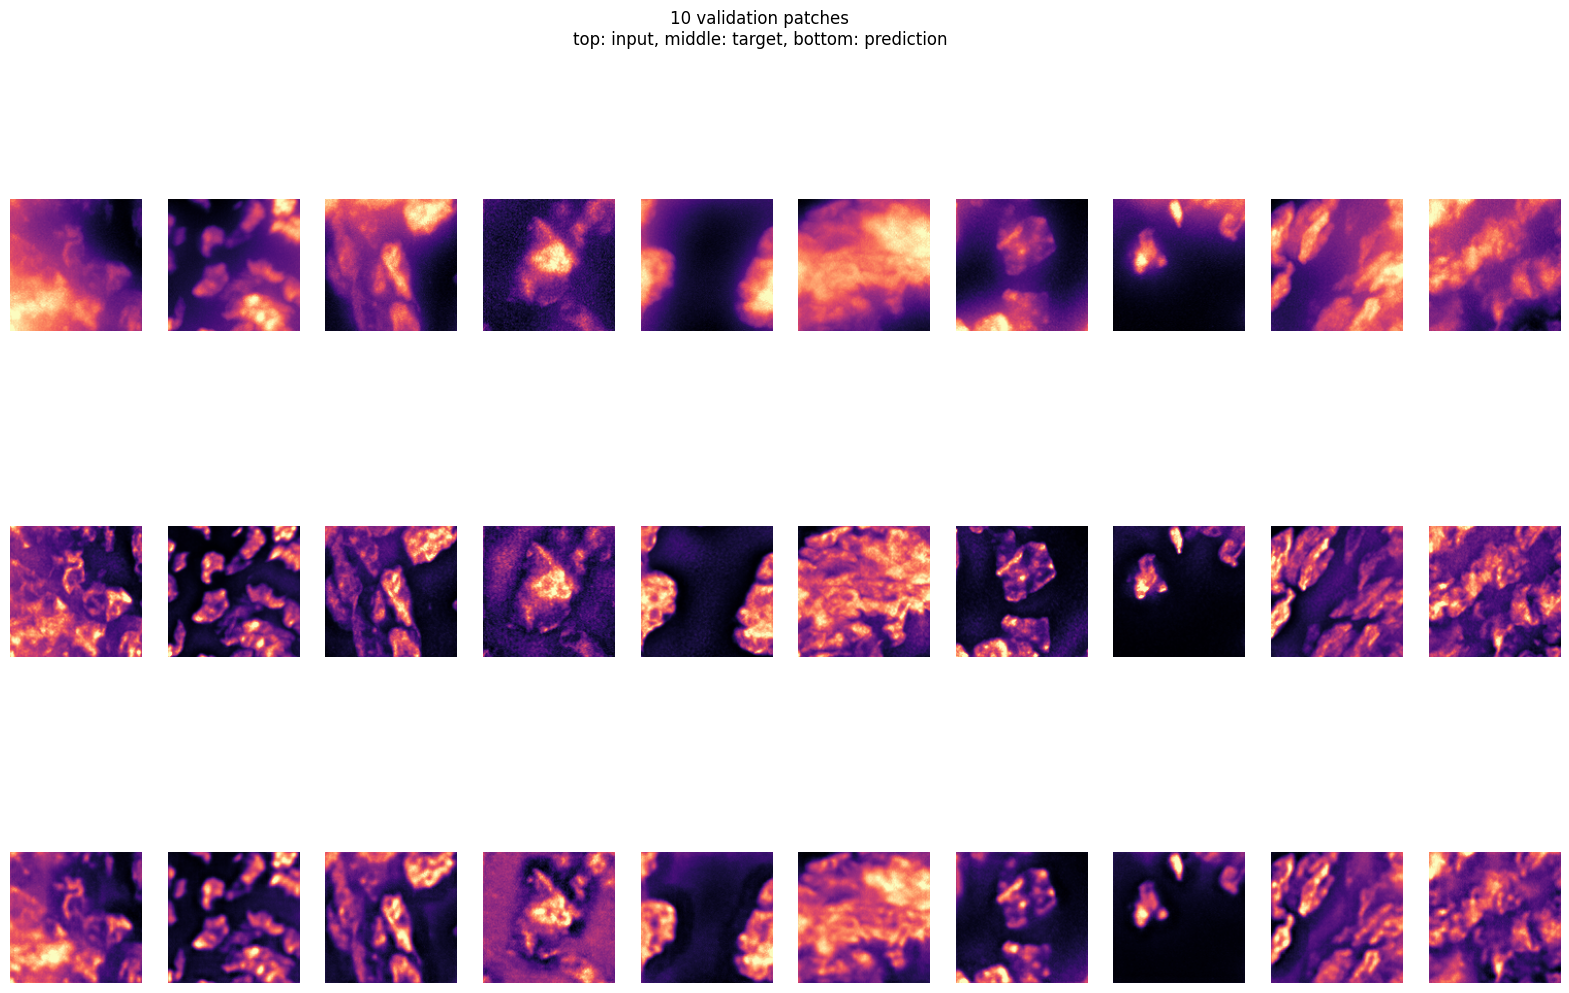

Validation prediction summary:
  MAE: 0.0505411
  MSE: 0.00601598


In [30]:
X_example, Y_example, Y_pred = predict_on_validation_examples(
    model=model,
    X_val=X_val,
    Y_val=Y_val,
    probabilistic=PROBABILISTIC,
    n_examples=10,
)

## Save training metadata

This stores:
- model hyperparameters
- patch file used
- patch metadata file
- patch-generation metadata
- data shapes
- normalization settings

In [31]:
metadata = build_training_metadata(
    care_root=CARE_ROOT,
    patch_dir=patch_dir,
    patch_file=patch_file,
    model_dir=MODEL_DIR,
    model_name=MODEL_NAME,
    validation_split=VALIDATION_SPLIT,
    train_batch_size=TRAIN_BATCH_SIZE,
    train_steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    train_epochs=TRAIN_EPOCHS,
    unet_kern_size=UNET_KERN_SIZE,
    unet_n_depth=UNET_N_DEPTH,
    train_learning_rate=TRAIN_LEARNING_RATE,
    train_loss=TRAIN_LOSS,
    probabilistic=PROBABILISTIC,
    axes=axes,
    X_shape=X.shape,
    Y_shape=Y.shape,
    X_val_shape=X_val.shape,
    Y_val_shape=Y_val.shape,
    n_channel_in=n_channel_in,
    n_channel_out=n_channel_out,
    normalization_enabled=NORMALIZE_PATCHES,
    normalization_pmin=NORMALIZATION_PMIN,
    normalization_pmax=NORMALIZATION_PMAX,
    normalization_eps=NORMALIZATION_EPS,
)

metadata_file = save_training_metadata(
    metadata,
    model_dir=MODEL_DIR,
    model_name=MODEL_NAME,
)

print("Metadata file:", metadata_file)

Saved training metadata: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_metadata.json
Metadata file: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_metadata.json


## Final output summary

In [32]:
print("Training complete.")
print("Patch file used:", patch_file)
print("Patch metadata file:", patch_metadata_file)
print("Model output directory:", (MODEL_DIR / MODEL_NAME).resolve())
print("Training history file:", history_file)
print("Training metadata file:", metadata_file)

Training complete.
Patch file used: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47.npz
Patch metadata file: /home/sagah/moldia-archive/CARE_training/train_patches/DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__metadata.json
Model output directory: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39
Training history file: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_history.json
Training metadata file: /home/sagah/moldia-archive/CARE_training/care_models/CARE__DAPI_ONLY_train_patches_Leica_40_signal_biased__2026-04-22_14-47__2026-04-22_15-39/training_metadata.json


## Load the model later

To load the trained model in another notebook:

```python
from csbdeep.models import CARE

model = CARE(
    config=None,
    name=MODEL_NAME,
    basedir=str(MODEL_DIR),
)